# Non-Survivorship-Biased Founder Departure Corpus

This notebook demonstrates `data.py`, the script that standardizes the founder-departure commit corpus (`github_founder_departure_commits_non_conditioned`) into the `exp_sel_data_out` schema.

It pools **two explicit sampling frames** into one dataset, tagged per-example via `metadata_sampling_frame`:

- **`liveness_non_conditioned`** — repos discovered via GitHub Search API queries (historical creation window 2009-2016, archived/stale filter, language sweep), with **no filter on current stars/fame/liveness**.
- **`liveness_conditioned`** — the 12 successfully-extracted repos from iter_1's hand-curated "currently prominent" candidate list, carried forward unmodified and retro-tagged.

Each example is a full per-repo record (`repo_metadata`, `commits[]`, `founder_signal`, `sampling_frame`, `frame_construction_method`), labeled `founder_dominant` / `not_founder_dominant` based on whether the top author's share of year-1 commits exceeds a threshold (0.7).

The demo below loads a small curated subset of the real per-repo records (`mini_demo_data.json`) and runs the **same** standardization logic as the original `data.py`.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru is not pre-installed on Colab
_pip('loguru==0.7.3')

# no other non-pre-installed packages needed (json/glob/os/collections are stdlib;
# matplotlib is pre-installed on Colab, installed locally below only)
if 'google.colab' not in sys.modules:
    _pip('matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
import json
from collections import Counter

from loguru import logger
import sys as _sys

logger.remove()
logger.add(_sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

import matplotlib.pyplot as plt

## Load the demo data

The original `data.py` reads per-repo records from `temp/repo_records/*.json` (this iteration's `liveness_non_conditioned` sweep) and from iter_1's `temp/checkpoint.json` (the `liveness_conditioned` list). For this demo, both are replaced by a single curated `mini_demo_data.json` containing 4 real per-repo records (the 1 successfully-extracted `liveness_non_conditioned` repo plus 3 small `liveness_conditioned` repos, commit lists truncated for file size) plus the original run's metadata, loaded from GitHub with a local fallback so this notebook runs both on Colab and locally.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-24ffbe-pre-departure-bus-factor-diffusion/main/round-2/dataset-1/demo/mini_demo_data.json"
import json, os

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
records = data["records"]
len(records)

4

## Config

All tunable parameters from the original script. `FOUNDER_SHARE_THRESHOLD` is the only real parameter in `data.py` (the share of year-1 commits from the top author above which a repo is labeled `founder_dominant`). `N_RECORDS` controls how many of the loaded demo records to process — set to the full demo set (11) since that already runs in seconds.

In [5]:
FOUNDER_SHARE_THRESHOLD = 0.7  # original value in data.py
N_RECORDS = len(records)  # use all demo records (runs in seconds)

## Standardization functions

Copied directly from `data.py`: `label_for` turns the founder-signal share into the classification label, and `record_to_example` turns a per-repo record into an `exp_sel_data_out`-schema example (the `input` field is the JSON-serialized repo data; everything else is flat `metadata_*` fields for filtering/stratification).

In [6]:
def label_for(share):
    if share is None:
        return "unknown"
    return "founder_dominant" if share >= FOUNDER_SHARE_THRESHOLD else "not_founder_dominant"


def record_to_example(record):
    input_obj = {
        "repo_metadata": record["repo_metadata"],
        "commits": record["commits"],
        "truncated": record["truncated"],
        "commit_cap": record["commit_cap"],
    }
    share = record["founder_signal"]["year1_top_author_share"]
    return {
        "input": json.dumps(input_obj),
        "output": label_for(share),
        "metadata_full_name": record["repo_metadata"]["full_name"],
        "metadata_stars": record["repo_metadata"]["stars"],
        "metadata_language": record["repo_metadata"]["language"],
        "metadata_history_years": record["repo_metadata"]["history_years"],
        "metadata_n_commits": record["repo_metadata"]["total_commit_count"],
        "metadata_truncated": record["truncated"],
        "metadata_year1_top_author_share": share,
        "metadata_task_type": "founder_dominance_classification",
        "metadata_sampling_frame": record["sampling_frame"],
        "metadata_frame_construction_method": record["frame_construction_method"],
        "metadata_archived": record["repo_metadata"].get("archived"),
    }

## Build the standardized examples

Mirrors `main()` in `data.py`: apply `record_to_example` across the loaded records, tallying how many come from each sampling frame. In the original script this loop was split into two sources (this iteration's `liveness_non_conditioned` sweep + iter_1's `liveness_conditioned` checkpoint); here both are already pooled in `records` (tagged via `metadata_sampling_frame`/`sampling_frame`), so the loop is a single pass over `records[:N_RECORDS]`.

In [7]:
examples = []
n_nc = 0
n_c = 0
for record in records[:N_RECORDS]:
    examples.append(record_to_example(record))
    if record["sampling_frame"] == "liveness_non_conditioned":
        n_nc += 1
    else:
        n_c += 1

logger.info(f"liveness_non_conditioned examples: {n_nc}, liveness_conditioned examples: {n_c}")
len(examples)

22:46:13|INFO   |liveness_non_conditioned examples: 1, liveness_conditioned examples: 3


4

## Assemble the final output object

Matches the `out = {"metadata": ..., "datasets": [...]}` structure `data.py` writes to `full_data_out.json`. The yield report (candidate discovery -> extraction success rate) is carried over from the original run's metadata, since this demo does not re-run the GitHub discovery/extraction pipeline.

In [8]:
metadata = dict(data["metadata"])
metadata["n_examples_total"] = len(examples)
metadata["n_liveness_non_conditioned"] = n_nc
metadata["n_liveness_conditioned"] = n_c

out = {"metadata": metadata, "datasets": [{"dataset": metadata["primary_dataset"], "examples": examples}]}
dataset_name = out["datasets"][0]["dataset"]
logger.info(f"assembled {len(examples)} examples into dataset '{dataset_name}'")

22:46:13|INFO   |assembled 4 examples into dataset 'github_founder_departure_commits_non_conditioned'


## Results

A readable summary table of the standardized examples, plus a plot of each repo's year-1 top-author commit share (the founder-dominance signal) split by sampling frame — this is exactly the axis the artifact exists to make visible: the `liveness_conditioned` (hand-curated "currently prominent") repos vs. the single `liveness_non_conditioned` repo actually extracted this iteration.

repo                             frame                    label                    share   stars
jquery-archive/jquery-metadata   liveness_non_conditioned not_founder_dominant     0.545     216
kennethreitz/records             liveness_conditioned     not_founder_dominant     0.600    7221
amoffat/sh                       liveness_conditioned     founder_dominant         0.928    7245
arrow-py/arrow                   liveness_conditioned     not_founder_dominant     0.483    9049

label counts: {'not_founder_dominant': 3, 'founder_dominant': 1}
sampling frame counts: {'liveness_non_conditioned': 1, 'liveness_conditioned': 3}


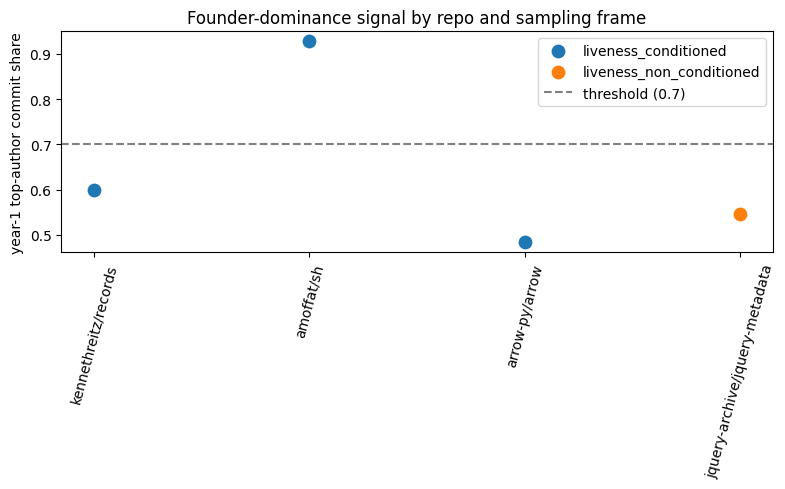

In [9]:
header = f"{'repo':32s} {'frame':24s} {'label':22s} {'share':>7s} {'stars':>7s}"
print(header)
for e in examples:
    share = e["metadata_year1_top_author_share"]
    share_s = f"{share:.3f}" if share is not None else "n/a"
    row = f"{e['metadata_full_name']:32s} {e['metadata_sampling_frame']:24s} {e['output']:22s} {share_s:>7s} {e['metadata_stars']:>7d}"
    print(row)

print()
print("label counts:", dict(Counter(e["output"] for e in examples)))
print("sampling frame counts:", dict(Counter(e["metadata_sampling_frame"] for e in examples)))

fig, ax = plt.subplots(figsize=(8, 5))
frames = sorted(set(e["metadata_sampling_frame"] for e in examples))
colors = {"liveness_conditioned": "tab:blue", "liveness_non_conditioned": "tab:orange"}
for frame in frames:
    xs = [e["metadata_full_name"] for e in examples if e["metadata_sampling_frame"] == frame]
    ys = [e["metadata_year1_top_author_share"] for e in examples if e["metadata_sampling_frame"] == frame]
    ax.scatter(xs, ys, label=frame, color=colors.get(frame), s=80)
ax.axhline(FOUNDER_SHARE_THRESHOLD, color="gray", linestyle="--", label=f"threshold ({FOUNDER_SHARE_THRESHOLD})")
ax.set_ylabel("year-1 top-author commit share")
ax.set_title("Founder-dominance signal by repo and sampling frame")
ax.tick_params(axis="x", rotation=75)
ax.legend()
plt.tight_layout()
plt.show()